In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Copy of Copy_of_Generated_Data_with_1500_datasets(1).csv')
df.head()

,Type of Lattice Structure,Strut Radius,Number of Struts,Weight in KG,Volume Fraction,Porosity,Critical Buckling Load in KN,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Simple Cubic,0.250000,12,0.329032,0.068144,0.931856,3.079110,NaN,NaN,NaN,NaN
1,Simple Cubic,0.251503,12,0.337746,0.069694,0.930306,3.137577,NaN,NaN,NaN,NaN
2,Simple Cubic,0.253006,12,0.346461,0.071235,0.928765,3.196744,NaN,NaN,NaN,NaN
3,Simple Cubic,0.254509,12,0.355176,0.072768,0.927232,3.256616,NaN,NaN,NaN,NaN
4,Simple Cubic,0.256012,12,0.363891,0.074292,0.925708,3.317194,NaN,NaN,NaN,NaN


In [ ]:
df.drop(["Unnamed: 7",	"Unnamed: 8",	"Unnamed: 9",	"Unnamed: 10"],axis=1,inplace=True)

In [ ]:
df

,Type of Lattice Structure,Strut Radius,Number of Struts,Weight in KG,Volume Fraction,Porosity,Critical Buckling Load in KN
0,Simple Cubic,0.250000,12,0.329032,0.068144,0.931856,3.079110
1,Simple Cubic,0.251503,12,0.337746,0.069694,0.930306,3.137577
2,Simple Cubic,0.253006,12,0.346461,0.071235,0.928765,3.196744
3,Simple Cubic,0.254509,12,0.355176,0.072768,0.927232,3.256616
4,Simple Cubic,0.256012,12,0.363891,0.074292,0.925708,3.317194
...,...,...,...,...,...,...,...
1495,FCC,0.993988,24,7.794865,0.786812,0.213188,325.730070
1496,FCC,0.995491,24,7.809117,0.787320,0.212680,326.923147
1497,FCC,0.996994,24,7.823370,0.787819,0.212181,328.118671
1498,FCC,0.998497,24,7.837622,0.788306,0.211694,329.316645


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Type of Lattice Structure     1500 non-null   object 
 1   Strut Radius                  1500 non-null   float64
 2   Number of Struts              1500 non-null   int64  
 3   Weight in KG                  1500 non-null   float64
 4   Volume Fraction               1500 non-null   float64
 5   Porosity                      1500 non-null   float64
 6   Critical Buckling Load in KN  1500 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 82.2+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df["Type of Lattice Structure"] = le.fit_transform(df["Type of Lattice Structure"])

In [ ]:
df

,Type of Lattice Structure,Strut Radius,Number of Struts,Weight in KG,Volume Fraction,Porosity,Critical Buckling Load in KN
0,2,0.250000,12,0.329032,0.068144,0.931856,3.079110
1,2,0.251503,12,0.337746,0.069694,0.930306,3.137577
2,2,0.253006,12,0.346461,0.071235,0.928765,3.196744
3,2,0.254509,12,0.355176,0.072768,0.927232,3.256616
4,2,0.256012,12,0.363891,0.074292,0.925708,3.317194
...,...,...,...,...,...,...,...
1495,1,0.993988,24,7.794865,0.786812,0.213188,325.730070
1496,1,0.995491,24,7.809117,0.787320,0.212680,326.923147
1497,1,0.996994,24,7.823370,0.787819,0.212181,328.118671
1498,1,0.998497,24,7.837622,0.788306,0.211694,329.316645


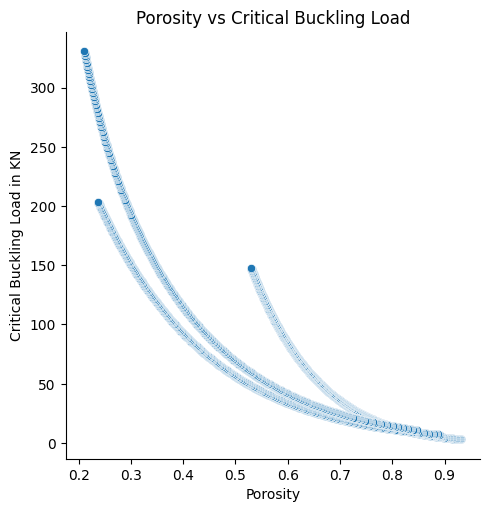

In [ ]:
plot = sns.relplot(df,x="Porosity",y="Critical Buckling Load in KN",kind="scatter")
plot.set(title="Porosity vs Critical Buckling Load")
plt.show()

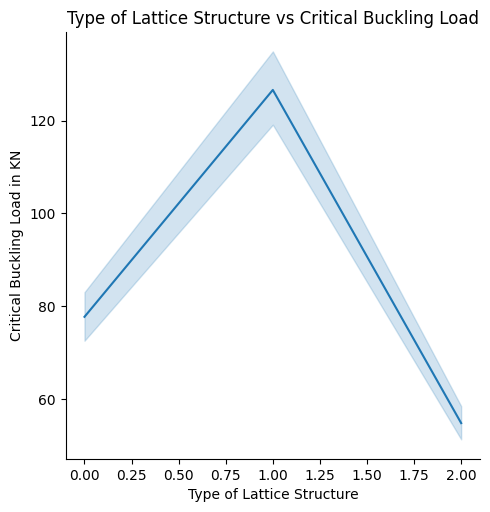

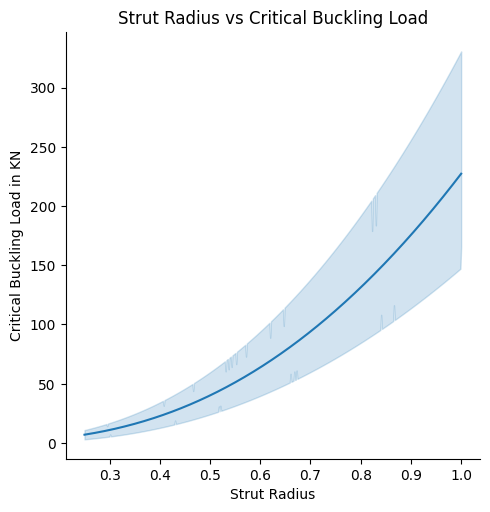

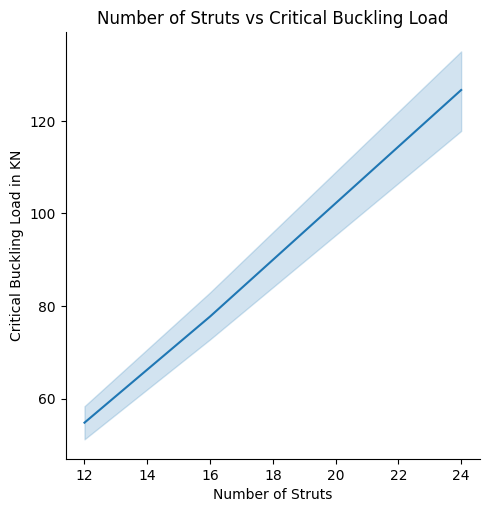

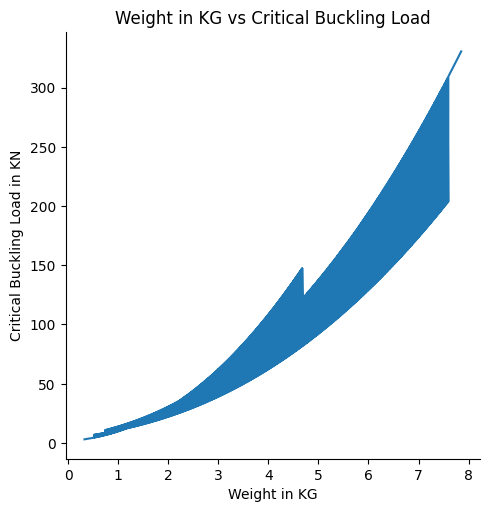

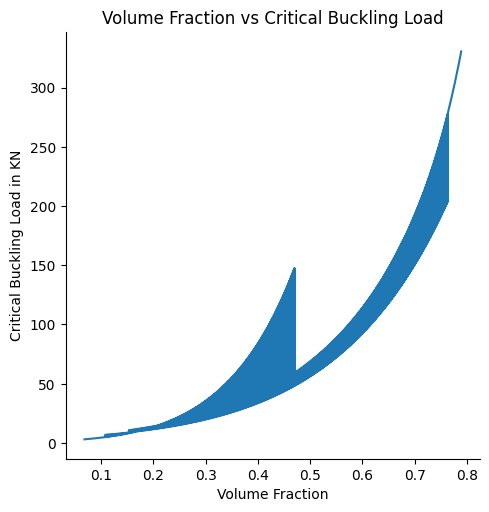

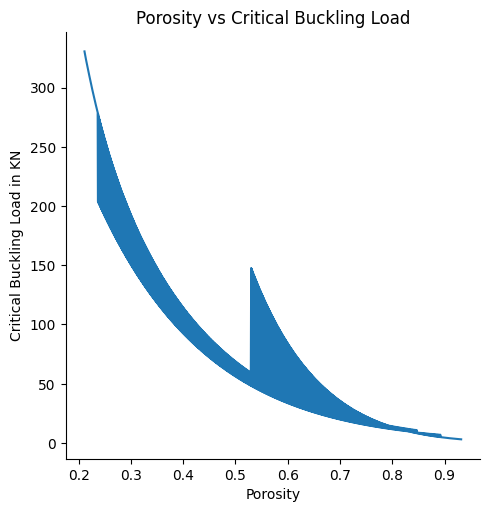

In [ ]:
for col in df.columns:
    if col != 'Critical Buckling Load in KN':
        plot = sns.relplot(df, x=col, y="Critical Buckling Load in KN", kind="line")
        plot.set(title=f"{col} vs Critical Buckling Load")
        plt.show()

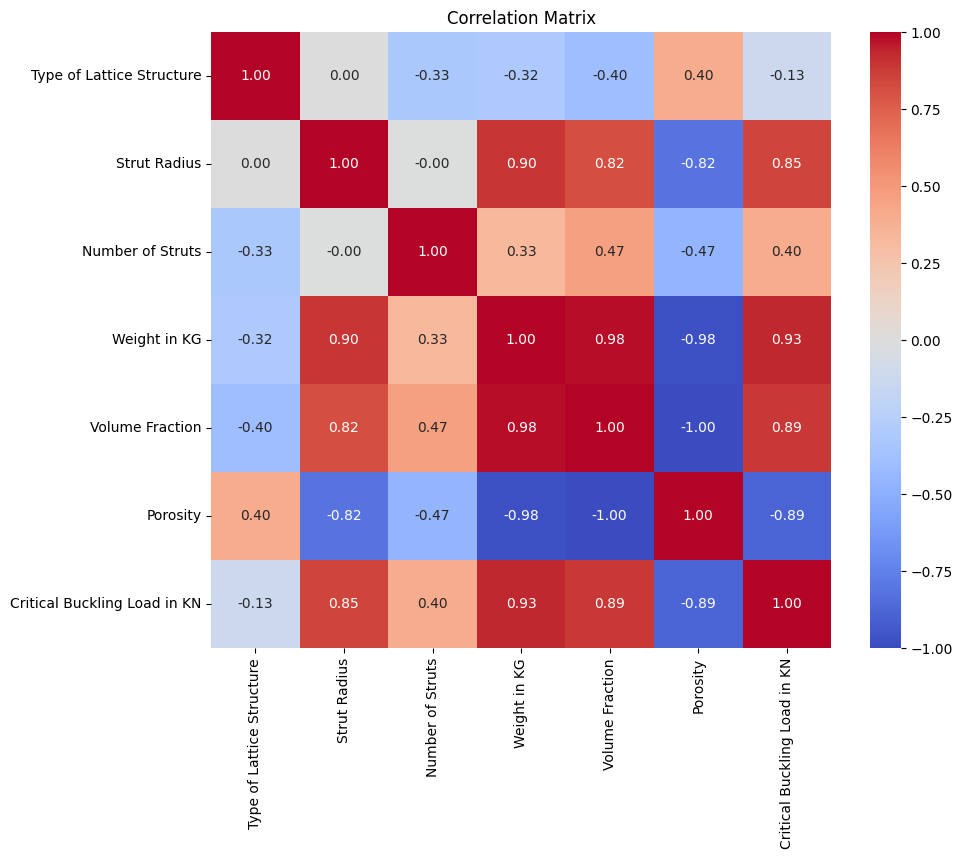

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
x = df.drop("Critical Buckling Load in KN",axis=1)
y = df["Critical Buckling Load in KN"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
X_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

In [ ]:
X_scaled

,Type of Lattice Structure,Strut Radius,Number of Struts,Weight in KG,Volume Fraction,Porosity
0,1.224745,-1.728590,-1.069045,-1.652311,-1.986980,1.986980
1,1.224745,-1.721662,-1.069045,-1.647934,-1.978919,1.978919
2,1.224745,-1.714734,-1.069045,-1.643558,-1.970903,1.970903
3,1.224745,-1.707806,-1.069045,-1.639181,-1.962932,1.962932
4,1.224745,-1.700877,-1.069045,-1.634805,-1.955005,1.955005
...,...,...,...,...,...,...
1495,0.000000,1.700877,1.336306,2.096990,1.750478,-1.750478
1496,0.000000,1.707806,1.336306,2.104147,1.753122,-1.753122
1497,0.000000,1.714734,1.336306,2.111305,1.755713,-1.755713
1498,0.000000,1.721662,1.336306,2.118462,1.758245,-1.758245


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 6)
X_test shape: (300, 6)
y_train shape: (1200,)
y_test shape: (300,)


In [ ]:
X_test

,Type of Lattice Structure,Strut Radius,Number of Struts,Weight in KG,Volume Fraction,Porosity
1116,0.000000,-0.924917,1.336306,-0.615689,-0.303483,0.303483
1368,0.000000,0.820994,1.336306,1.187992,1.303353,-1.303353
422,1.224745,1.195117,-1.069045,0.194575,-0.096341,0.096341
413,1.224745,1.132763,-1.069045,0.155186,-0.121272,0.121272
451,1.224745,1.396036,-1.069045,0.321493,-0.018489,0.018489
...,...,...,...,...,...,...
983,-1.224745,1.617739,-0.267261,1.882604,1.561619,-1.561619
799,-1.224745,0.342947,-0.267261,0.572883,0.679658,-0.679658
1265,0.000000,0.107387,1.336306,0.450773,0.776600,-0.776600
1150,0.000000,-0.689358,1.336306,-0.372335,-0.016923,0.016923


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
li = LinearRegression()

In [ ]:
Model = li.fit(X_train,y_train)

In [ ]:
Model.score(X_test,y_test)

0.9667204577588215

In [ ]:
y_pred = Model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 172.49
R-squared Score: 0.97


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


y_pred_rf = rf.predict(X_test)


mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest R-squared Score: {r2_rf:.2f}")

Random Forest Mean Squared Error: 24.04
Random Forest R-squared Score: 1.00


In [ ]:
rf.score(X_test,y_test)

0.9953627877544128

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)


y_pred = model.predict(X_poly_test)


mse_poly = mean_squared_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(f"Polynomial Regression Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial Regression R-squared Score: {r2_poly:.2f}")


Polynomial Regression Mean Squared Error: 0.00
Polynomial Regression R-squared Score: 1.00


In [ ]:
model.score(X_poly_test,y_test)

0.9999999786028767

In [ ]:

new_data_point = np.array([[2, 0.250000, 12, 0.329032, 0.068144, 0.931856]])


new_data_point_scaled = scaler.transform(new_data_point)

new_data_point_poly = poly.transform(new_data_point_scaled)


predicted_load = model.predict(new_data_point_poly)

print(f"Predicted Critical Buckling Load in KN: {predicted_load[0]:.2f}")

Predicted Critical Buckling Load in KN: 3.19


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


y_pred_knn = knn.predict(X_test)


mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Regression Mean Squared Error: {mse_knn:.2f}")
print(f"KNN Regression R-squared Score: {r2_knn:.2f}")

KNN Regression Mean Squared Error: 0.25
KNN Regression R-squared Score: 1.00


In [ ]:
knn.score(X_test,y_test)

0.9999513899556596

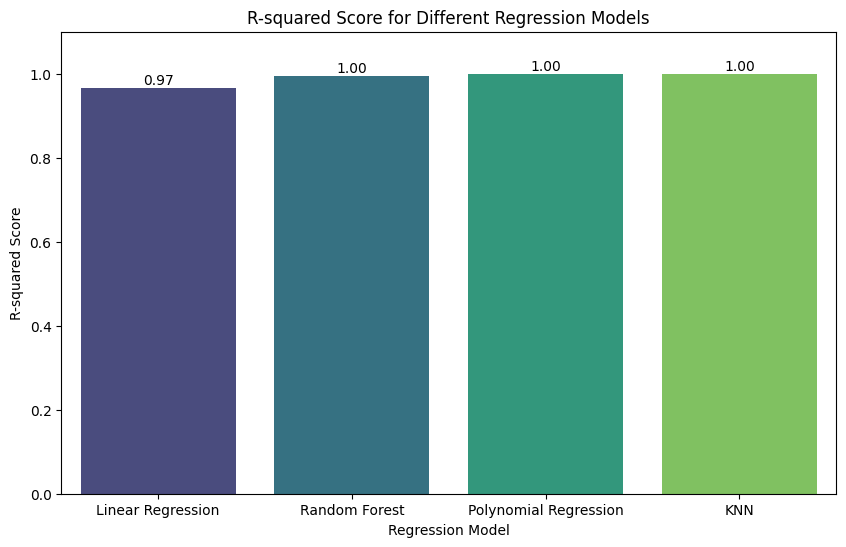

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

model_scores = {
    'Linear Regression': r2,
    'Random Forest': r2_rf,
    'Polynomial Regression': r2_poly,
    'KNN': r2_knn
}


scores_series = pd.Series(model_scores)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=scores_series.index, y=scores_series.values, palette='viridis')
plt.title('R-squared Score for Different Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.ylim(0, 1.1)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

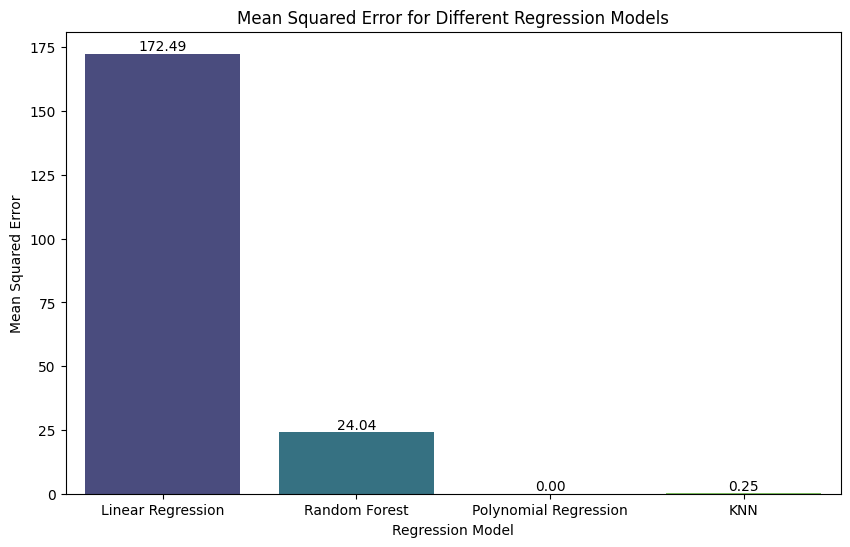

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
model_mse_scores = {
    'Linear Regression': mse,
    'Random Forest': mse_rf,
    'Polynomial Regression': mse_poly,
    'KNN': mse_knn
}
mse_scores_series = pd.Series(model_mse_scores)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=mse_scores_series.index, y=mse_scores_series.values, palette='viridis')
plt.title('Mean Squared Error for Different Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('Mean Squared Error')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('scaler', scaler),
    ('poly_features', poly),
    ('regressor', model)
])


new_client_data = np.array([[1,	0.993988,	24,	7.794865	,0.786812,	0.213188]])


predicted_load_pipeline = pipeline.predict(new_client_data)

print(f"Predicted Critical Buckling Load using Pipeline: {predicted_load_pipeline[0]:.2f}")

Predicted Critical Buckling Load using Pipeline: 325.76


In [ ]:
import joblib


pipeline_filename = 'critical_buckling_load_pipeline.joblib'


joblib.dump(pipeline, pipeline_filename)

print(f"Pipeline saved to '{pipeline_filename}'")

Pipeline saved to 'critical_buckling_load_pipeline.joblib'


In [ ]:
df

In [ ]:

from joblib import load

model = load("critical_buckling_load_pipeline.joblib")


In [ ]:
import pandas as pd


data = pd.DataFrame({
    "Type of Lattice Structure": [2],
    "Strut Radius": [0.25],
    "Number of Struts": [12],
    "Weight in KG": [0.32],
    "Volume Fraction": [0.068],
    "Porosity": [0.93]
})

prediction = model.predict(data)
print("Predicted Critical Buckling Load:", prediction)


Predicted Critical Buckling Load: [-2843.51313326]


In [ ]:
import joblib


knn_filename = 'knn_model.joblib'

joblib.dump(knn, knn_filename)

print(f"KNN model saved to '{knn_filename}'")

KNN model saved to 'knn_model.joblib'


In [ ]:
import joblib
import pandas as pd
import numpy as np

loaded_knn_model = joblib.load('knn_model.joblib')


new_client_data_point = pd.DataFrame({
    "Type of Lattice Structure": [2],
    "Strut Radius": [0.25],
    "Number of Struts": [12],
    "Weight in KG": [0.32],
    "Volume Fraction": [0.068],
    "Porosity": [0.93]
})

new_client_data_point_scaled = scaler.transform(new_client_data_point)
prediction = loaded_knn_model.predict(new_client_data_point_scaled)

print("Predicted Critical Buckling Load:", prediction)

Predicted Critical Buckling Load: [3.19744839]
